In [8]:
import qutip
import matplotlib
from qutip.piqs.piqs  import *
import numpy as np
import os
os.environ["MOSEKLM_LICENSE_FILE"] = "/Users/46668993/Desktop/qer/mosek/mosek.lic"  # adjust path
from noisemodel import*
from codewords import*
from optimisation import*
import matplotlib.pyplot as plt

I think the first thing to do before any experiment is to verify if the optimisation is giving us the correct output. Experiment the 4-qubit code against amplitude damping noise.

In [23]:
def four_qubit(*, return_qutip: bool = True):
    """
    4-qubit code (full Hilbert space, not symmetric subspace).
    
    Codewords:
      |0_L> = (|0000> + |1111>)/√2
      |1_L> = (|0011> + |1100>)/√2
    
    Returns: (rho, l0, l1) either as qutip.Qobj or numpy arrays
    """
    n = 4
    dim = 2**n
    
    def idx_from_bitstr(bitstr: str) -> int:
        """Convert binary string to 1-based index (MATLAB style) then to 0-based."""
        return int(bitstr, 2)  # 0-based indexing in Python
    
    # |0_L>
    ket0L = np.zeros(dim, dtype=complex)
    ket0L[idx_from_bitstr('0000')] = 1/np.sqrt(2)
    ket0L[idx_from_bitstr('1111')] = 1/np.sqrt(2)
    
    # |1_L>
    ket1L = np.zeros(dim, dtype=complex)
    ket1L[idx_from_bitstr('0011')] = 1/np.sqrt(2)
    ket1L[idx_from_bitstr('1100')] = 1/np.sqrt(2)
    
    # Normalize (already normalized, but for safety)
    ket0L = ket0L / np.linalg.norm(ket0L)
    ket1L = ket1L / np.linalg.norm(ket1L)
    
    # Create maximally mixed state on codespace
    #rho = code_maximally_mixed_on_codespace(ket0L, ket1L)
    rho = 0.5* (np.outer(ket0L, ket0L.conj()) + np.outer(ket1L, ket1L.conj()))
    
    # Reshape to column vectors
    l0 = ket0L.reshape(-1, 1)
    l1 = ket1L.reshape(-1, 1)
    
    if return_qutip:
        return as_qutip_objects(rho, l0, l1)
    return rho, l0, l1
def local_ampdamp(gamma: float, dim: int) -> List[np.ndarray]:
    """
    Generate Kraus operators for local amplitude damping noise on N qubits.
    
    Args:
        gamma: Damping parameter in [0, 1]
        dim: Hilbert space dimension (must be 2^N for some integer N)
    
    Returns:
        List of Kraus operators (numpy arrays)
    """
    # Validate dim
    if not isinstance(dim, int) or dim < 2:
        raise ValueError('dim must be an integer >= 2 (and equal to 2^N).')
    
    # Validate gamma
    if not (np.isscalar(gamma) and np.isreal(gamma) and 0 <= gamma <= 1):
        raise ValueError('gamma must be a real scalar in [0, 1].')
    
    # Check if dim is a power of 2
    N = int(np.round(np.log2(dim)))
    if 2**N != dim:
        raise ValueError('dim must be exactly a power of 2 (dim = 2^N).')
    
    # Single-qubit amplitude damping Kraus operators
    E0 = np.array([[1, 0], 
                   [0, np.sqrt(1 - gamma)]], dtype=complex)
    E1 = np.array([[0, np.sqrt(gamma)], 
                   [0, 0]], dtype=complex)
    E = [E0, E1]
    
    # Build N-qubit Kraus operators
    numK = 2**N
    Kraus = []
    
    for s in range(numK):
        # Convert s to binary representation (N bits, MSB first)
        bits = [(s >> (N - 1 - q)) & 1 for q in range(N)]
        
        # Build tensor product
        K = np.array([[1]], dtype=complex)  # Start with scalar 1
        for q in range(N):
            K = np.kron(K, E[bits[q]])
        
        Kraus.append(K)
    
    return Kraus    




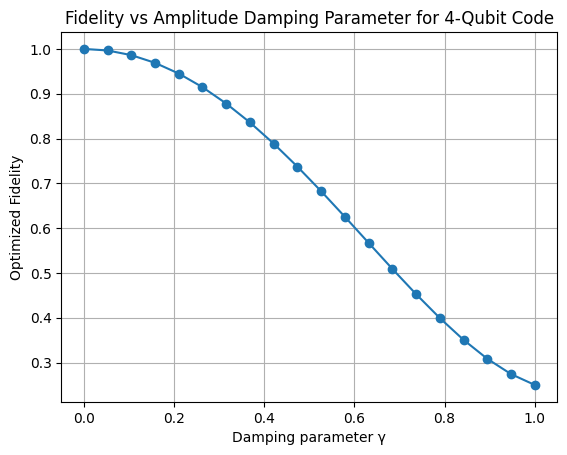

In [28]:
rho, l0, l1 = four_qubit(return_qutip=False)
gamma = np.linspace(0,1,20)
fid = []
dim = rho.shape[0]
for g in gamma:
    kraus = local_ampdamp(g, dim)
    fidelity = optimise(qutip.Qobj(l0), qutip.Qobj(l1), [qutip.Qobj(k) for k in kraus], 
    solver = 'mosek')
    fid.append(fidelity)
plt.plot(gamma, fid, marker='o')
plt.xlabel('Damping parameter γ')
plt.ylabel('Optimized Fidelity')
plt.title('Fidelity vs Amplitude Damping Parameter for 4-Qubit Code')
plt.grid()    



 done for gamma value: 0.00001 
 done for gamma value: 0.00001 
 done for gamma value: 0.00002 
 done for gamma value: 0.00003 
 done for gamma value: 0.00004 
 done for gamma value: 0.00006 
 done for gamma value: 0.00009 
 done for gamma value: 0.00013 
 done for gamma value: 0.00018 
 done for gamma value: 0.00026 
 done for gamma value: 0.00038 
 done for gamma value: 0.00055 
 done for gamma value: 0.00078 
 done for gamma value: 0.00113 
 done for gamma value: 0.00162 
 done for gamma value: 0.00234 
 done for gamma value: 0.00336 
 done for gamma value: 0.00483 
 done for gamma value: 0.00695 
 done for gamma value: 0.01000 


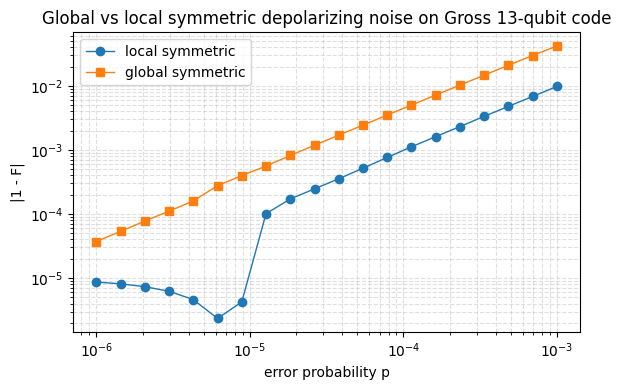

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from codewords import gross_13
from noisemodel import noisemodel
from optimisation import optimise 

rho, l0, l1 = gross_13(phi=0.0)
gamma = np.logspace(-5, -2, 20)
dt = 0.1

infids_local = []
infids_global = []

for g in gamma:
    kraus_global = noisemodel('global symmetric depolarizing', 13, g, dt)
    kraus_local = noisemodel('local symmetric depolarizing', 13, g, dt)

    fid_local = optimise(l0, l1, kraus_local, solver='mosek')
    fid_global = optimise(l0, l1, kraus_global, solver='mosek')
    print(f" done for gamma value: {g:.5f} ")

    infids_local.append(abs(1.0 - float(fid_local)))
    infids_global.append(abs(1.0 - float(fid_global)))

infids_local = np.array(infids_local, dtype=float)
infids_global = np.array(infids_global, dtype=float)
p_vals = gamma * dt

# avoid log(0)
mask_local = infids_local > 0
mask_global = infids_global > 0

plt.figure(figsize=(6, 4))
plt.loglog(p_vals[mask_local], infids_local[mask_local], "o-", lw=1, label="local symmetric")
plt.loglog(p_vals[mask_global], infids_global[mask_global], "s-", lw=1, label="global symmetric")
plt.xlabel("error probability p")
plt.ylabel("|1 - F|")
plt.title("Global vs local symmetric depolarizing noise on Gross 13-qubit code")
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


I will compare the bgm code's global symmetric plots with matlab's. 
The key difference here is block diagonal representation, use of PIQS(which shouldnt matter), and mosek solver in cvxpy. 

In [15]:
b=3; g=3; m=2; 
N = 2*b*m + g; 
[rho, l0, l1] = bgmcode_piqs(b, g, m, return_qutip=True)
gamma = np.logspace(-5, -2, 20)
dt = 0.1
infids_global = []
infids_local = []
for g in gamma: 
    kraus_global = noisemodel('global symmetric depolarizing', N, g, dt)
    kraus_local = noisemodel('local symmetric depolarizing', N, g, dt)
    fid_global = optimise(l0, l1, kraus_global, solver='mosek')
    fid_local = optimise(l0, l1, kraus_local, solver='mosek')
    print(f" done for gamma value: {g:.5f} ")
    infids_global.append(abs(1.0 - float(fid_global)))
    infids_local.append(abs(1.0 - float(fid_local)))

infids_global = np.array(infids_global, dtype=float)
infids_local = np.array(infids_local, dtype=float)
p_vals = gamma * dt
# avoid log(0)
mask_local = infids_local > 0
mask_global = infids_global > 0
plt.figure(figsize=(6, 4))
plt.loglog(p_vals[mask_local], infids_local[mask_local], "o-", lw=1, label="local symmetric")
plt.loglog(p_vals[mask_global], infids_global[mask_global], "s-", lw=1, label="global symmetric")
plt.xlabel("error probability p")
plt.ylabel("|1 - F|")
plt.title("Global vs local symmetric depolarizing noise on (3,3,2)-bgm code")
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


 done for gamma value: 0.00001 
 done for gamma value: 0.00001 
 done for gamma value: 0.00002 
 done for gamma value: 0.00003 
 done for gamma value: 0.00004 
 done for gamma value: 0.00006 
 done for gamma value: 0.00009 
 done for gamma value: 0.00013 
 done for gamma value: 0.00018 
 done for gamma value: 0.00026 
 done for gamma value: 0.00038 
 done for gamma value: 0.00055 
 done for gamma value: 0.00078 
 done for gamma value: 0.00113 
 done for gamma value: 0.00162 
 done for gamma value: 0.00234 
 done for gamma value: 0.00336 
 done for gamma value: 0.00483 
 done for gamma value: 0.00695 
 done for gamma value: 0.01000 


NameError: name 'plt' is not defined

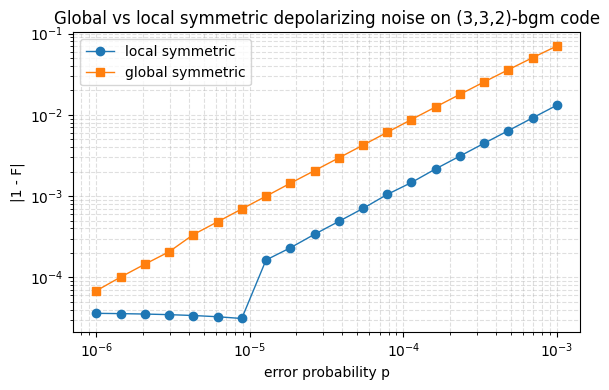

In [17]:
plt.figure(figsize=(6, 4))
plt.loglog(p_vals[mask_local], infids_local[mask_local], "o-", lw=1, label="local symmetric")
plt.loglog(p_vals[mask_global], infids_global[mask_global], "s-", lw=1, label="global symmetric")
plt.xlabel("error probability p")
plt.ylabel("|1 - F|")
plt.title("Global vs local symmetric depolarizing noise on (3,3,2)-bgm code")
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

I will compare the 3,3,1 bgm code (that corrects 1 error) with 5,5,2 bgm code (that can correct 2 errors) and 7,7,3 (that can correct 3 error). 

In [1]:
import os
os.environ["MOSEKLM_LICENSE_FILE"] = "/Users/46668993/Desktop/qer/mosek/mosek.lic"

import qutip
import matplotlib
from qutip.piqs.piqs import *
import numpy as np
from noisemodel import *
from codewords import *
from optimisation import *
import matplotlib.pyplot as plt
import time

In [ ]:
import os
os.environ["MOSEKLM_LICENSE_FILE"] = "/Users/46668993/Desktop/qer/mosek/mosek.lic"

import qutip
import matplotlib
from qutip.piqs.piqs import *
import numpy as np
from noisemodel import *
from codewords import *
from optimisation import *
import matplotlib.pyplot as plt
import time
import gc  # garbage collection

# Compare (b,g,m) codes against global depolarizing noise
#codes = [(3, 3, 2), (5, 5, 2)]
codes = [(5, 5, 2)]
gamma = np.logspace(-5, -2, 4)
dt = 0.1
p_vals = np.array(gamma) * dt

plt.figure(figsize=(6, 4))

for b, g_code, m in codes:
    N = 2 * b * m + g_code
    print(f"\n{'='*60}")
    print(f"Processing (b,g,m)=({b},{g_code},{m}), N={N} qubits")
    print(f"{'='*60}")
    
    rho, l0, l1 = bgmcode_piqs(b, g_code, m, return_qutip=True)
    infids_global = []
    infids_local = []
    
    for g in gamma:
        print(f"Processing gamma={g:.2e}")

        try:
            # Global depolarizing
            t0 = time.perf_counter()
            kraus_global = noisemodel('global symmetric depolarizing', N, g, dt, 'choi')
            t1 = time.perf_counter()
            print(f"  Global kraus in {t1 - t0:.2f}s")

            fid_global = optimise(l0, l1, kraus_global, solver='mosek')
            t2 = time.perf_counter()
            print(f"  Global optimise in {t2 - t1:.2f}s")
            
            infids_global.append(abs(1.0 - float(fid_global)))
            
            # Delete large objects immediately after use
            del kraus_global
            gc.collect()  # Force garbage collection
            
        except Exception as e:
            print(f"  ERROR (global): {e}")
            infids_global.append(np.nan)

        try:
            # Local depolarizing
            t3 = time.perf_counter()
            kraus_local = noisemodel('local symmetric depolarizing', N, g, dt, 'choi')
            t4 = time.perf_counter()
            print(f"  Local kraus in {t4 - t3:.2f}s")

            fid_local = optimise(l0, l1, kraus_local, solver='mosek')
            t5 = time.perf_counter()
            print(f"  Local optimise in {t5 - t4:.2f}s")
            
            infids_local.append(abs(1.0 - float(fid_local)))
            
            # Delete large objects immediately after use
            del kraus_local
            gc.collect()  # Force garbage collection
            
        except Exception as e:
            print(f"  ERROR (local): {e}")
            infids_local.append(np.nan)

    # Process results
    infids_global = np.array(infids_global, dtype=float)
    infids_local = np.array(infids_local, dtype=float)
    mask_global = (infids_global > 0) & np.isfinite(infids_global)
    mask_local = (infids_local > 0) & np.isfinite(infids_local)
    
    if np.any(mask_global):
        plt.loglog(p_vals[mask_global], infids_global[mask_global], "o-", lw=1, label=f"bgm ({b},{g_code},{m}) global")
    if np.any(mask_local):
        plt.loglog(p_vals[mask_local], infids_local[mask_local], "s--", lw=1, label=f"bgm ({b},{g_code},{m}) local")

    # Clean up large objects for this code
    del rho, l0, l1, infids_global, infids_local
    gc.collect()

plt.xlabel("error probability p")
plt.ylabel("|1 - F|")
plt.title("Global vs local depolarizing noise for bgm codes")
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


Processing (b,g,m)=(5,5,2), N=25 qubits
Processing gamma=1.00e-05
